<a href="https://colab.research.google.com/github/yogitaalone04-web/machine-learning-practicals/blob/main/Random_Forest_Gaming_Mental_Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS24D017: Yogita Alone

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/ML_Dataset/Gaming and Mental Health.csv"
df = pd.read_csv(path)

df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [4]:
df.shape

(1000, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [6]:
df.columns

Index(['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre',
       'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality',
       'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa',
       'work_productivity_score', 'mood_state', 'mood_swing_frequency',
       'withdrawal_symptoms', 'loss_of_other_interests',
       'continued_despite_problems', 'eye_strain', 'back_neck_pain',
       'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score',
       'face_to_face_social_hours_weekly', 'monthly_game_spending_usd',
       'years_gaming', 'gaming_addiction_risk_level'],
      dtype='object')

In [7]:
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


In [8]:
df.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [9]:
df = df.dropna()

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
df.head()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,...,mood_state_Normal,mood_state_Restless,mood_state_Withdrawn,mood_swing_frequency_Never,mood_swing_frequency_Often,mood_swing_frequency_Rarely,mood_swing_frequency_Sometimes,gaming_addiction_risk_level_Low,gaming_addiction_risk_level_Moderate,gaming_addiction_risk_level_Severe
1,21,3.0,7.2,3.75,2.0,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,20,7.2,5.1,1.62,2.0,True,True,False,True,True,...,False,False,True,False,False,False,False,False,False,False
5,21,2.1,7.5,3.81,4.0,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
6,21,2.7,7.2,1.82,6.0,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
13,22,5.1,5.3,3.25,6.0,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False


In [12]:
df.columns

Index(['age', 'daily_gaming_hours', 'sleep_hours', 'grades_gpa',
       'work_productivity_score', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain',
       ...
       'mood_state_Normal', 'mood_state_Restless', 'mood_state_Withdrawn',
       'mood_swing_frequency_Never', 'mood_swing_frequency_Often',
       'mood_swing_frequency_Rarely', 'mood_swing_frequency_Sometimes',
       'gaming_addiction_risk_level_Low',
       'gaming_addiction_risk_level_Moderate',
       'gaming_addiction_risk_level_Severe'],
      dtype='object', length=505)

In [13]:
X = df.drop([
    "gaming_addiction_risk_level_Low",
    "gaming_addiction_risk_level_Moderate",
    "gaming_addiction_risk_level_Severe"
], axis=1)

Y = df["gaming_addiction_risk_level_Severe"]

In [14]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [15]:
X.head()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,...,mood_state_Irritable,mood_state_Normal,mood_state_Restless,mood_state_Withdrawn,mood_swing_frequency_Never,mood_swing_frequency_Often,mood_swing_frequency_Rarely,mood_swing_frequency_Sometimes,gaming_addiction_risk_level_Low,gaming_addiction_risk_level_Moderate
1,21,3.0,7.2,3.75,2.0,False,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False
3,20,7.2,5.1,1.62,2.0,True,True,False,True,True,...,False,False,False,True,False,False,False,False,False,False
5,21,2.1,7.5,3.81,4.0,False,False,False,False,False,...,False,True,False,False,True,False,False,False,True,False
6,21,2.7,7.2,1.82,6.0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
13,22,5.1,5.3,3.25,6.0,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [16]:
Y.head()

,gaming_addiction_risk_level_Severe
1,False
3,False
5,False
6,False
13,False


In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=42
)

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",      # you can change to "entropy"
    max_depth=None,
    random_state=42
)

In [20]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [21]:
Y_pred = rf_model.predict(X_test)

In [22]:
print("Accuracy Score:", accuracy_score(Y_test, Y_pred))

Accuracy Score: 0.9069767441860465


In [24]:
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))


Confusion Matrix:
[[111   1]
 [ 11   6]]


In [27]:
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.99      0.95       112
        True       0.86      0.35      0.50        17

    accuracy                           0.91       129
   macro avg       0.88      0.67      0.72       129
weighted avg       0.90      0.91      0.89       129



In [28]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
7,continued_despite_problems,0.103245
1,daily_gaming_hours,0.093407
14,monthly_game_spending_usd,0.073365
12,social_isolation_score,0.059791
11,exercise_hours_weekly,0.056502
...,...,...
290,record_id_GD0612,0.000000
292,record_id_GD0619,0.000000
294,record_id_GD0625,0.000000
295,record_id_GD0627,0.000000


In [29]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<BarContainer object of 504 artists>

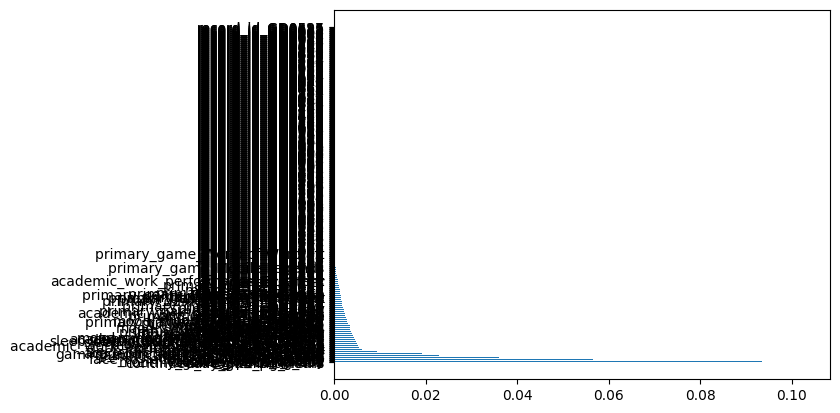

In [30]:
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])

Text(0.5, 0, 'Importance')

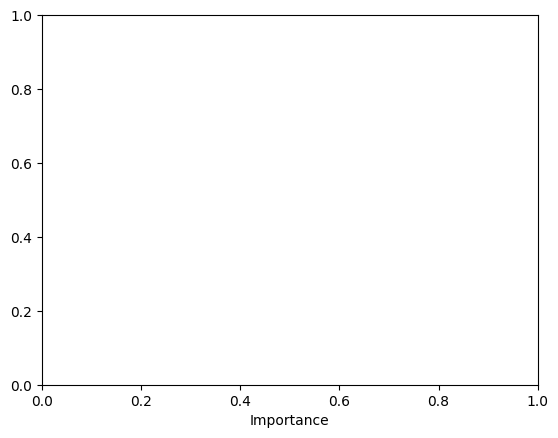

In [31]:
plt.xlabel("Importance")

Text(0.5, 1.0, 'Feature Importance - Random Forest')

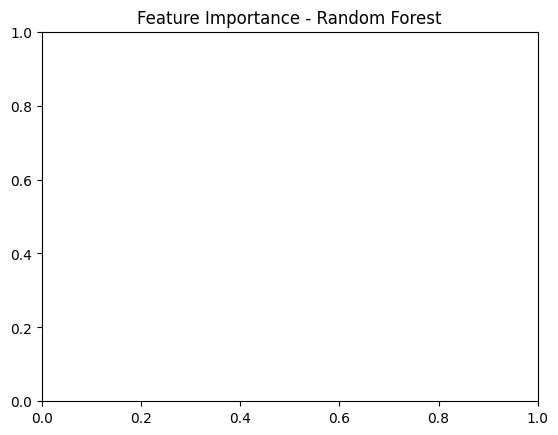

In [32]:
plt.title("Feature Importance - Random Forest")

In [33]:
estimators = [10, 50, 100, 200]
accuracies = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(Y_test, y_pred))

In [34]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

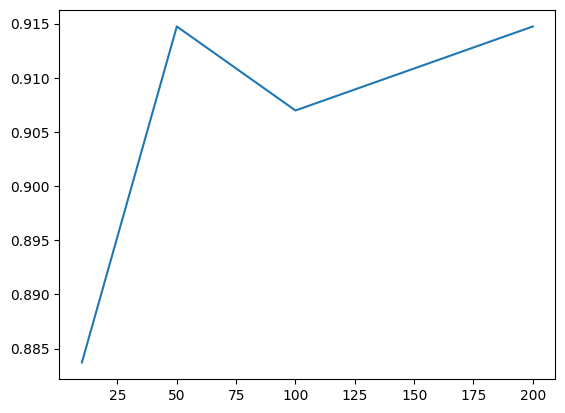

In [35]:
plt.plot(estimators, accuracies)

Text(0.5, 0, 'Number of Trees')

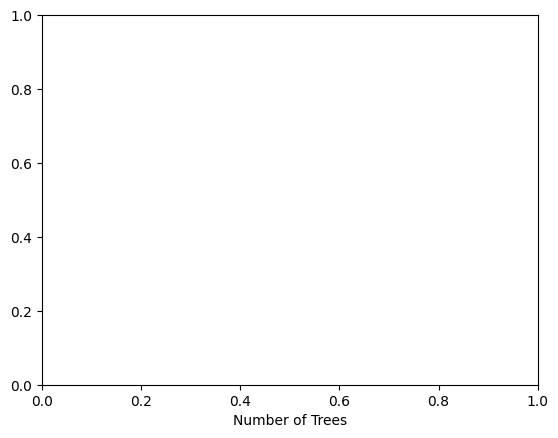

In [36]:
plt.xlabel("Number of Trees")

Text(0, 0.5, 'Accuracy')

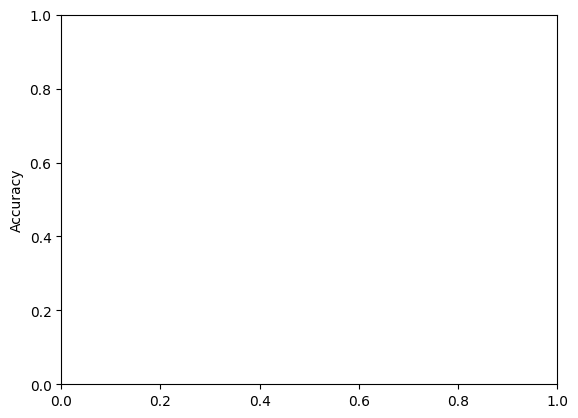

In [37]:
plt.ylabel("Accuracy")

Text(0.5, 1.0, 'Effect of n_estimators on Accuracy')

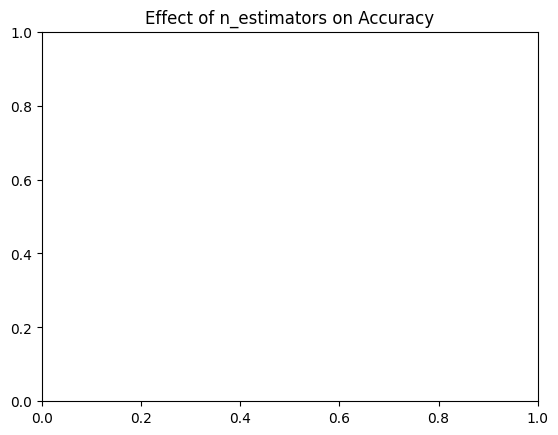

In [38]:
plt.title("Effect of n_estimators on Accuracy")